Boissier, S., & Prantzos, N. 1999, MNRAS, 307, 857

Boissier, S., & Prantzos, N. 2000, MNRAS, 312, 398

mc-spf DATA/Coma/NGC4848/region_photometry.fits filters.txt --sfh 'SFHs_Boissier/Models_B120VEL_radius_5_Z0.020_bc03hr.fits' FITPHOT

mc-spf DATA/GMP3779/region_photometry.fits filters.txt --sfh 'SFHs_Boisser/Models_B120VEL_radius_5_Z0.020_bc03hr.fits' --timerange '12500,13500' PLOT

mc-spf DATA/GMP3779/region_photometry.fits filters.txt --sfh 'SFHs_Boisser/Models_B120VEL_radius_5_Z0.020_bc03hr.fits' FIT



# Scaling relation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Scaling relations

Rd_MW = 2.6                # kpc
Sigma_0_MW = 1150          # solar masses / pc2
Vc_MW = 220                # km/s
spin_MW = 0.03 
md_MW = 0.05
M_MW = 1e12                 # Msun
Md_MW = 0.05 * 1e12         # Msun

md = 0.05
jd = 0.05

def M(Vc):
    return  M_MW * (Vc / Vc_MW)**3

def Md(Vc,md):
    return  md * M(Vc)

def Rd(Vc,spin):
    return  Rd_MW * (spin / spin_MW) * (Vc / Vc_MW)

def Sigma_0(Vc,spin): 
    return Sigma_0_MW * (md / md_MW) * (spin / spin_MW)**-2 * (Vc / Vc_MW)

def surface_density(R,Vc,spin):
    return Sigma_0(Vc,spin) * np.exp(-R/Rd(Vc,spin))


def Vc_to_Md(Vc): return Md(Vc,md = 0.05)
def Md_to_Vc(Md): return Vc_MW * (Md / Md_MW)**(1/3)
    

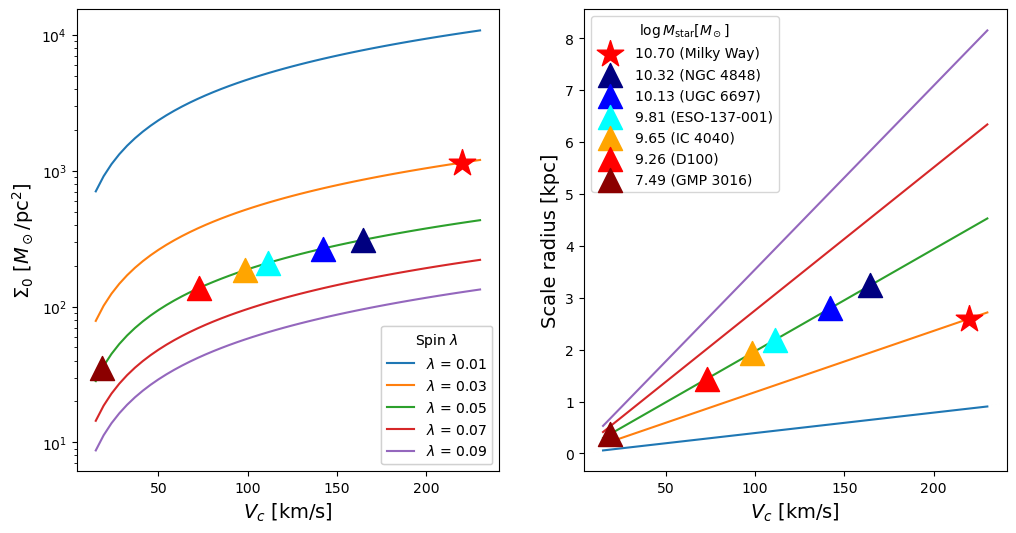

In [7]:
# --- Galaxy Sample ---
sample_galaxies = {
    'NGC 4848': 10.32,
    'UGC 6697': 10.13,
    'ESO-137-001': 9.81,
    'IC 4040': 9.65,
    'D100': 9.26,
    'GMP 3016': 7.49
}

colors = ['navy','blue', 'cyan', 'orange', 'red', 'darkred']

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
v = np.linspace(15, 230)

# Plot model curves for different spin parameters
spin_values = [0.01, 0.03, 0.05, 0.07, 0.09]
spin_handles = []

for l in spin_values:
    h0, = ax[0].plot(v, Sigma_0(v, l), label=f'$\lambda$ = {l:.2f}')
    h1, = ax[1].plot(v, Rd(v, l), label=f'$\lambda$ = {l:.2f}')
    spin_handles.append(h0)  # store only one handle per spin


galaxy_handles = []
h = ax[0].scatter(Vc_MW, Sigma_0_MW, marker='*', c='red', edgecolor='red', s=400, label=f"{np.log10(Vc_to_Md(220)):.2f} (Milky Way)",zorder=5)
ax[1].scatter(Vc_MW, Rd_MW, marker='*', c='red', edgecolor='red', s=400,zorder=5)
galaxy_handles.append(h)

for i, gal in enumerate(sample_galaxies.keys()):
    logMd = sample_galaxies[gal]
    Md_val = 10**logMd
    Vc_gal = Md_to_Vc(Md_val)
    Sigma_0_gal = Sigma_0(Vc_gal, 0.05)
    Rd_gal = Rd(Vc_gal, 0.05)

    h = ax[0].scatter(Vc_gal, Sigma_0_gal, color = colors[i], marker='^', s=300, label=f"{sample_galaxies[gal]} ({gal})",zorder=5)
    ax[1].scatter(Vc_gal, Rd_gal, color = colors[i], marker='^', s=300,zorder=5)
    galaxy_handles.append(h)

# Axis labels
for i in range(2):
    ax[i].set_xlabel('$V_c$ [km/s]',fontsize=14)
ax[0].set_ylabel(r'$\Sigma_0$ [$M_\odot$/pc$^2$]',fontsize=14)
ax[1].set_ylabel('Scale radius [kpc]',fontsize=14)
ax[0].set_yscale('log')

# Two legends on left panel
spin_legend = ax[0].legend(handles=spin_handles, loc='lower right', title='Spin $\lambda$')
ax[0].add_artist(spin_legend)
ax[1].legend(handles=galaxy_handles, loc='upper left', title='$\log M_\\text{star} [M_\odot]$')

# Secondary axes created ONCE and BEFORE plt.show()
#secax0 = ax[0].secondary_xaxis('top', functions=(Vc_to_Md, Md_to_Vc))
#secax1 = ax[1].secondary_xaxis('top', functions=(Vc_to_Md, Md_to_Vc))
#secax0.set_xlabel('$M_d$ [$M_\\odot$]')
#secax1.set_xlabel('$M_d$ [$M_\\odot$]')

#plt.tight_layout()
plt.show()



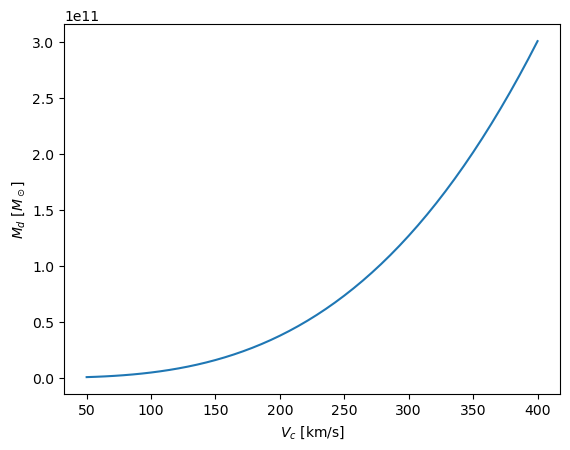

In [8]:
V_array = np.linspace(50,400)

fig,ax=plt.subplots()
ax.plot(V_array, Vc_to_Md(V_array))
#ax.set_aspect('equal')

ax.set_xlabel('$V_c$ [km/s]')
ax.set_ylabel('$M_d$ [$M_\odot$]')

plt.show()


In [9]:
# Velocity curves
from scipy.interpolate import interp1d
from scipy.special import iv as I, kv as K

G = 4.301e-6         # (kpc * (km/s)^2) / M_sun
rho0 = 0.015 * 1e9   # M_sun/kpc^3   0.008 - 0.015
Rc_MW = 5            # kpc -5 to 10

def Rc(Vc,spin):
    return Rc_MW * (spin/spin_MW) * (Vc/Vc_MW)

def rho_0(Vc,spin):
    return Vc**2 / (4*np.pi*G*Rc(Vc,spin)**2)


def velocity_profile(Vc, spin, disk=True):

    R = np.linspace(0.03, 50, 500)

    # Disk component
    sigma_0 = Sigma_0(Vc, spin)
    rd = Rd(Vc, spin)
    y = R / (2*rd)
    Vd_squared = 4 * np.pi * G * (sigma_0 * 1e6) * rd * y**2 * (I(0, y) * K(0, y) - I(1, y) * K(1, y))
    
    # Halo component
    rho0_val = rho_0(Vc, spin)
    rc = Rc(Vc, spin)
    Vh_squared = 4 * np.pi * G * rho0_val * rc**2 * (1 - (rc / R) * np.arctan(R / rc))

    # Total rotation curve
    V_total = np.sqrt(Vd_squared + Vh_squared)

    V_interp = interp1d(R, V_total, kind='linear', bounds_error=False, fill_value='extrapolate')

    return V_interp


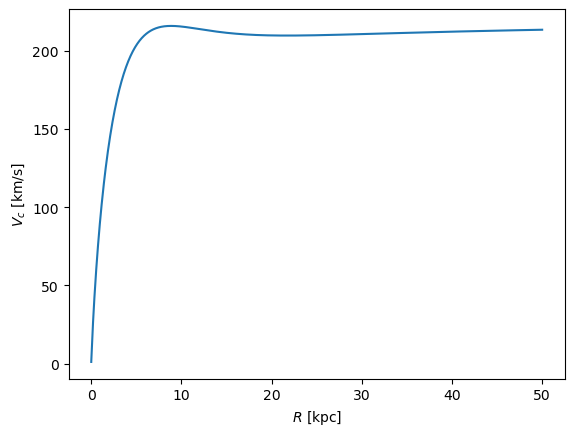

In [10]:
fig,ax = plt.subplots()

r = np.linspace(0,50,1000)
plt.plot(r,velocity_profile(220,0.03)(r))

ax.set_xlabel('$R$ [kpc]')
ax.set_ylabel('$V_c$ [km/s]')

plt.show()

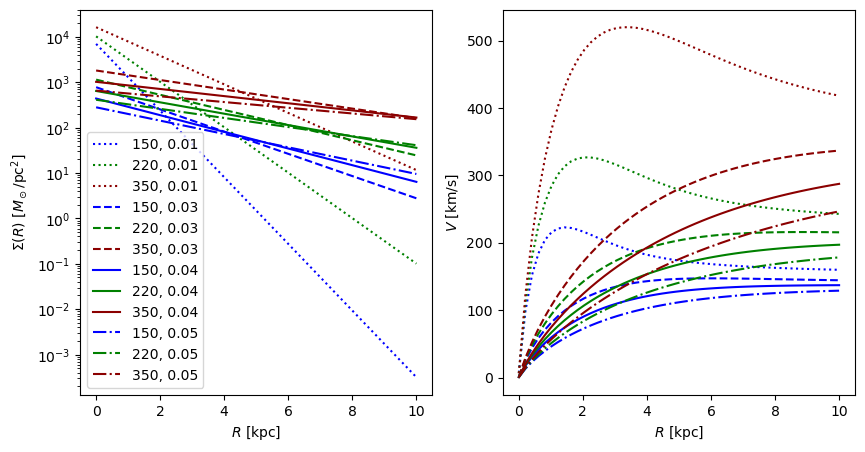

In [11]:
fig,ax = plt.subplots(1,2,figsize=(10,5))


r = np.linspace(0,10)

for l,ls in zip([0.01,0.03,0.04,0.05], [':','--','-','-.']):
    for Vc,c in zip([150,220,350], ['blue','green','darkred']):

        ax[0].plot(r,surface_density(r,Vc,l),linestyle=ls,color=c,label=f'{Vc}, {l}')
        ax[0].set_yscale('log')
        ax[0].set_xlabel('$R$ [kpc]')
        ax[0].set_ylabel('$\Sigma(R)$ [$M_\odot$/pc$^2$]')

        ax[0].legend()
        
        ax[1].plot(r, velocity_profile(Vc,l)(r),linestyle=ls,color=c)
        ax[1].set_xlabel('$R$ [kpc]')
        ax[1].set_ylabel('$V$ [km/s]')


# Boissier models

In [12]:
import os, glob, re
import numpy as np

# Base directory containing the “DISKEVOL.RES_L0.05_V*” files
data_dir = "SFHs_Boissier/boissier_models_big_grid"

# Pattern to match files without “lignes” in their name
file_pattern = os.path.join(data_dir, "DISKEVOL.RES_L0.05_V*")

# Regex to extract the integer velocity after “_V”
vel_pattern = re.compile(r"_V(\d+)")
# First, collect (velocity, full_path) pairs
velocity_files = []
for full_path in glob.glob(file_pattern):
    fname = os.path.basename(full_path)
    if "lignes" in fname:
        continue
    m = vel_pattern.search(fname)
    if not m:
        continue
    velocity = int(m.group(1))
    velocity_files.append((velocity, full_path))

# Sort by velocity (ascending)
velocity_files.sort(key=lambda vf: vf[0])

# Now build the dictionary in sorted order
boissier_models = {}
for velocity, full_path in velocity_files:
    boissier_models[velocity] = {}   # Initialize nested dict for this velocity

    current_radius = None
    boissier_models_by_radius = {}   # Temporary storage: radius → list of rows

    with open(full_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("99999"):
                # Skip empty lines or separator lines
                continue

            if line.startswith("R ="):
                parts = line.split()
                try:
                    # Parse “R = 1.24 kpc” → radius = 1.24
                    current_radius = float(parts[2])
                    boissier_models_by_radius[current_radius] = []
                except (IndexError, ValueError):
                    current_radius = None
                continue

            if current_radius is None:
                continue

            parts = line.split()
            if len(parts) < 6:
                continue

            try:
                # Convert columns 1–5 to float
                row = [float(x) for x in parts[1:6]]
                boissier_models_by_radius[current_radius].append(row)
            except ValueError:
                continue

    # Convert each list of rows into a NumPy array, then store under data[velocity]
    for radius, rows in boissier_models_by_radius.items():
        boissier_models[velocity][radius] = np.array(rows)

# Example: print out velocity → radius → array shape (velocities will be in ascending order)
#for v in data:
#    for r in sorted(data[v]):
#        arr = data[v][r]
#        print(f"Velocity = {v} km/s, Radius = {r:.2f} kpc → Shape = {arr.shape}")



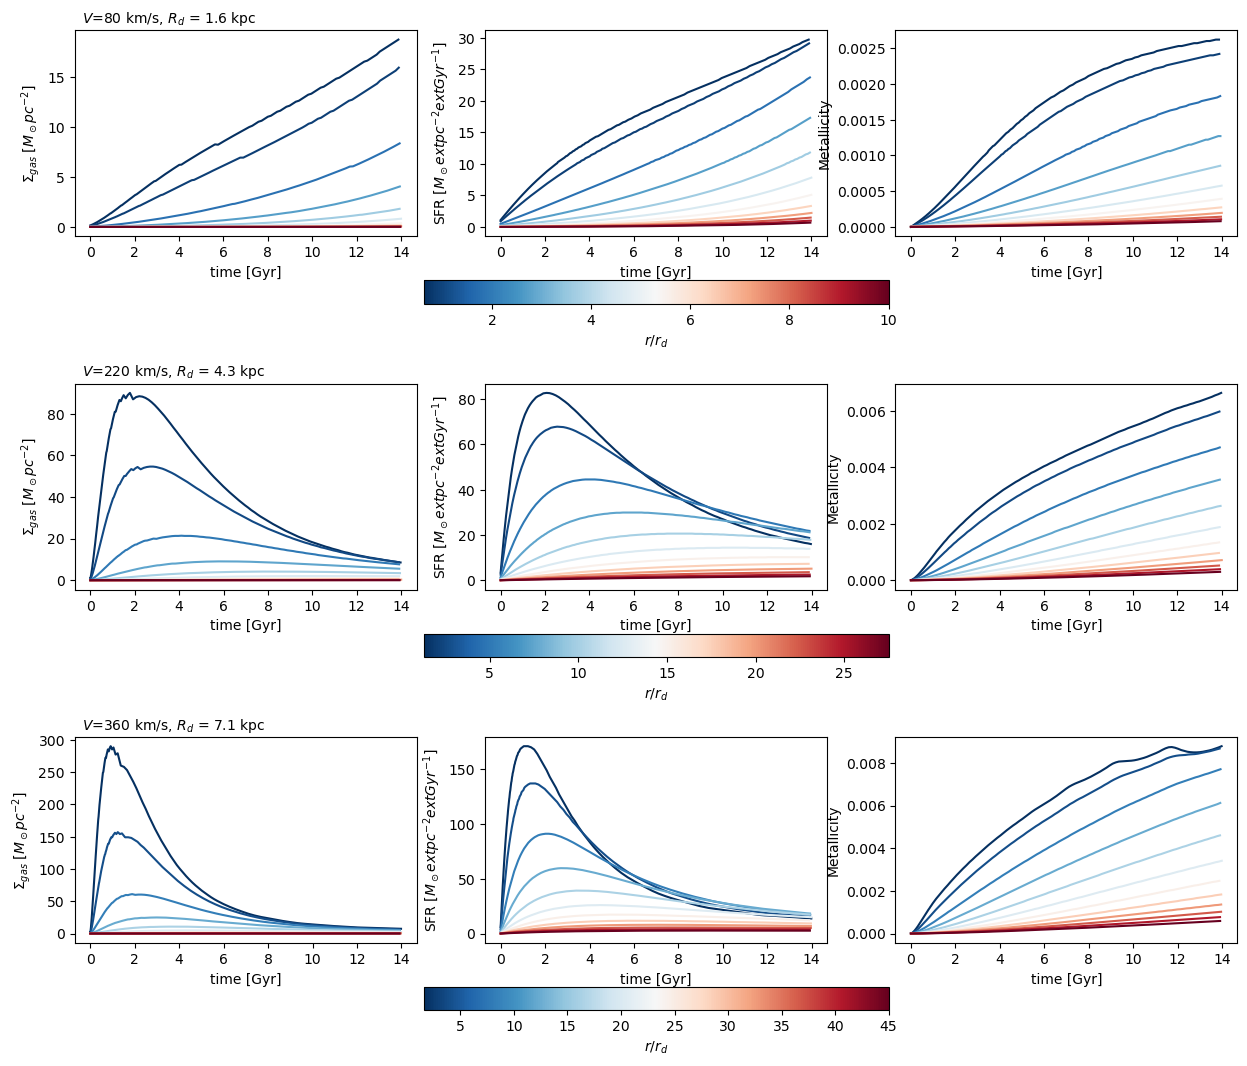

In [13]:
fig,ax = plt.subplots(3,3,figsize=(15,13))

for k,v in enumerate([80,220,360]):

    rd = Rd(v,0.05)                         # scale radius
    radii = sorted(boissier_models[v].keys())
    r_min, r_max = radii[0], radii[-1]
    norm = plt.Normalize(vmin=r_min, vmax=r_max)

    cmap = plt.cm.RdBu_r
    
    for r in radii:
        
        c = cmap(norm(r))
        
        t = boissier_models[v][r][:,0]
        sigma = boissier_models[v][r][:,1]
        sfr = boissier_models[v][r][:,2]
        Z = boissier_models[v][r][:,3]

        ax[k,0].plot(t,sigma,color=c,label=f"{r/rd:.2f}")
        ax[k,1].plot(t,sfr,color=c)
        ax[k,2].plot(t,Z,color=c)

    # Add a colorbar for this row, showing radii / rd
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(radii)
    cbar = fig.colorbar(sm, ax=ax[k, :], orientation='horizontal', pad=0.15,shrink=0.4)
    cbar.set_label(r"$r/r_d$")


    for i in range(3): ax[k,i].set_xlabel('time [Gyr]')
    ax[k, 0].set_ylabel('$\Sigma_{gas}$ [$M_\odot pc^{-2}$]')
    ax[k, 1].set_ylabel('SFR [$M_\odot \text{pc}^{-2} \text{Gyr}^{-1}$]')
    ax[k, 2].set_ylabel("Metallicity")
    ax[k,0].text(0.02, 1.1, f"$V$={v} km/s, $R_d$ = {rd:.1f} kpc", transform=ax[k,0].transAxes, va="top", ha="left")

#plt.tight_layout()
plt.show()


In [107]:

Q_TRUNC_ARRAY = []
TAU_Q_ARRAY = []
BURST_FACTORS_ARRAY = []
METALLICITY_ARRAY = []


def truncated_boissier_sfh(V, R, Q_age, tau_Q, burst_factor, data=boissier_models):

    # --- Select model data ---
    v_array = np.array(list(data.keys()))
    closest_v = v_array[np.argmin(np.abs(v_array - V))]
    #print("Closest velocity:", closest_v)

    r_array = np.array(list(data[closest_v].keys()))
    closest_r = r_array[np.argmin(np.abs(r_array - R))]
    #print("Closest radius:", closest_r)

    selected_data = data[closest_v][closest_r]
    
    AGE = 13500  # Myr    

    # Parameters
    t_trunc = AGE - Q_age    # truncation age
    burst_duration = 10.0    # duration of burst [Myr]
    t_burst_start = t_trunc - burst_duration
    t_burst_end = t_trunc


    # --- CIGALE SFH grid setup ---
    t_myr = selected_data[:, 0] * 1000.0
    sfr_myr = selected_data[:, 2]
    full_time_grid = np.arange(0, AGE + 1)

    interp = np.interp(full_time_grid, t_myr, sfr_myr, left=0.0, right=0.0)

    # --- Apply burst (rectangular increase) ---
    sfr_with_burst = interp.copy()
    burst_mask = (full_time_grid >= t_burst_start) & (full_time_grid < t_burst_end)
    sfr_with_burst[burst_mask] *= (1+burst_factor)

    # --- Apply exponential truncation ---
    sfr_trunc = sfr_with_burst.copy()
    sfr_ttrunc = np.interp(t_trunc, full_time_grid, sfr_with_burst)
    mask_trunc = full_time_grid > t_trunc
    sfr_trunc[mask_trunc] = sfr_ttrunc * np.exp(-(full_time_grid[mask_trunc] - t_trunc) / tau_Q)

    return full_time_grid, sfr_trunc



def truncated_boissier_SEDs(
    V,R,filename,
        SFH_QUENCHING_AGE,
        SFH_QUENCHING_TAU,
        BURST_FACTORS,
        METALLICITIES,
    data=boissier_models,
    ):

    AGE = 13500

    #print("Wrote truncated SFH to:", tmp_filename)
    # Create fits file
    #FITS HDU container
    hdu_list = fits.HDUList()

    # FITS primary extension (no data, header only)
    primary_hdu = fits.PrimaryHDU()
    hdu_list.append(primary_hdu)

    Nmodels = len(SFH_QUENCHING_AGE)*len(SFH_QUENCHING_TAU)*len(BURST_FACTORS)*len(METALLICITIES)
    print(' ... generating {0} models'.format(Nmodels))
    hdu_list[0].header['NEXT'] = Nmodels+1
    hdu_list[0].header['PAR1'] = 'TRUNCAGE'
    hdu_list[0].header['PAR2'] = 'TRUNCTAU'
    hdu_list[0].header['PAR3'] = 'BURST_FACTOR'
    hdu_list[0].header['PAR4'] = 'METALLICITY'
    hdu_list[0].header['SFHFUNC'] = 'exptrunc'

    # We use itertools.product to compute all the combinations of parameters.
    for (Q_age, tau_Q, burst_factor, metallicity) in tqdm(
            itertools.product(SFH_QUENCHING_AGE, SFH_QUENCHING_TAU, BURST_FACTORS, METALLICITIES),
            total=Nmodels,
            desc="Processing combinations"
        ):
    

        full_time_grid, sfr_trunc = truncated_boissier_sfh(V, R, Q_age, tau_Q, burst_factor, data=boissier_models)
    
        # Create a temporary filename (you can also choose a fixed path)
        tmp = tempfile.NamedTemporaryFile(suffix=".dat", delete=False)
        tmp_filename = tmp.name
        tmp.close()
    
        with open(tmp_filename, "w") as fout:
            for ti, si in zip(full_time_grid, sfr_trunc):
                fout.write(f"{int(ti):d}   {si:.6e}\n")

        # Initialisation of a new galaxy / SED
        galaxy = SED()
        sfh_module = get_module(
            'sfhfromfile',
            filename=tmp_filename,  #  your two‐column ASCII file
            sfr_column=1,           # it will read column 0 as time, column 1 as SFR
            age=AGE,
            normalise=True
        )
        ssp_module = get_module(
            'cb19',  #better than 'bc03'
            imf=1,   #Chabrier
            metallicity=metallicity
        )
    
        #Process the secular evolution
        sfh_module.process(galaxy)
        ssp_module.process(galaxy)
        wave = galaxy.wavelength_grid*10 #In Angstrom

        #This is the luminosity density from the stellar components in W/nm
        stellar_luminosity = (galaxy.luminosities['stellar.young']+galaxy.luminosities['stellar.old'])
        #This is the flux density from the stellar components in W/m2/nm at 10 parsec
        stellar_flux = utils.luminosity_to_flux(stellar_luminosity, 10. * parsec)
        #Convert into cgs units (erg/cm2/s/A) 1000 for w/m2 to erg/cm2/s and 0.1 for nm to A
        stellar_flux_cgs = stellar_flux*100

        #Fraction of the total luminosity in the young component
        frac_young =  galaxy.luminosities['stellar.young']/stellar_luminosity
    
        fitsimage = np.empty((len(galaxy.wavelength_grid),2), dtype=np.float32)
        fitsimage[:,0] = stellar_flux_cgs
        fitsimage[:,1] = frac_young
        spectrum_hdu = fits.ImageHDU(fitsimage)


        spectrum_hdu.header['IMF'] = "Chabrier"
        spectrum_hdu.header['VELOCITY'] = V
        spectrum_hdu.header['AGE'] = AGE
        spectrum_hdu.header['SEPAGE'] = galaxy.info['stellar.old_young_separation_age']
        spectrum_hdu.header['TRUNCTY']  = 'exp_burst'
        spectrum_hdu.header['TRUNCAGE'] = Q_age
        spectrum_hdu.header['TRUNCTAU'] = tau_Q
        spectrum_hdu.header['BURSTFAC'] = burst_factor
        spectrum_hdu.header['METAL'] = metallicity
        spectrum_hdu.header['MSTAR']    = galaxy.info['stellar.m_star']
        spectrum_hdu.header['MSTARYOU'] = galaxy.info['stellar.m_star_young']
        spectrum_hdu.header['MSTAROLD'] = galaxy.info['stellar.m_star_old']
        spectrum_hdu.header['NLYYOUNG'] = galaxy.info['stellar.n_ly_young']
        spectrum_hdu.header['NLYOLD']   = galaxy.info['stellar.n_ly_old']
        spectrum_hdu.header['LHAYOUNG'] = galaxy.info['stellar.n_ly_young']*1.37E-12 #From Osterbrock & ferland 2006 result in erg/s       
        spectrum_hdu.header['LHAOLD']   = galaxy.info['stellar.n_ly_old']*1.37E-12   #From Osterbrock & ferland 2006

        hdu_list.append(spectrum_hdu)
        os.remove(tmp_filename)

    hdu_list[0].data = np.array(wave, dtype=np.float32)
    hdu_list.writeto(filename, overwrite=True)

        

    

In [108]:
t,sfr = truncated_boissier_sfh(V=160,R=1,Q_age=150,tau_Q=5,burst_factor=2,data=boissier_models)

(13000.0, 13500.0)

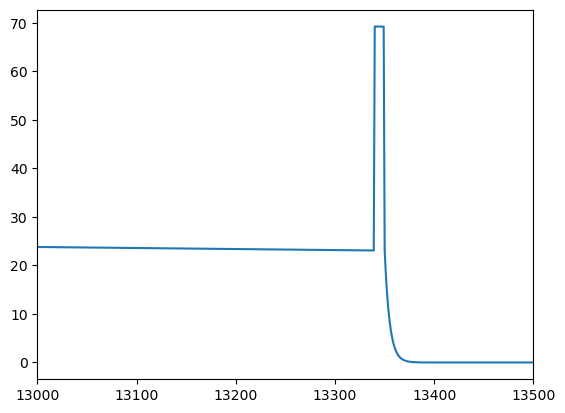

In [109]:
plt.plot(t,sfr)
plt.xlim(13000,13500)

In [110]:
# SFH quenching  #Lookback time for quenching Myr and attenuation factor for quenching
SFH_QUENCHING_TAU    = [10,30,100,1000] #[2,8,12,16,20,28,30,35,40,45,50,75,100,125,150,175,200,250,300,400,500,1000]
SFH_QUENCHING_AGE    = [10,100,500]     #[10,20,30,40,50,60,70,80,90,100,120,140,160,180,200,240,280,300,350,400,450,500,550,600,650,700,800,900,1000]
#SFH_QUENCHING_TAU    = [1,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,35,40,45,50,75,100,125,150,175,200,250,300,350,400,450,500,600,700,800,900,1000,2000]
#SFH_QUENCHING_AGE    = [2,4,6,8,10,20,30,40,50,60,70,80,90,100,120,140,160,180,200,220,240,260,280,300,325,350,375,400,425,450,475,500,550,600,650,700,750,800,850,900,950,1000,1500,2000,2500,3000]
BURST_FACTOR = [0,0.5,1]
# Bruzual and Charlot SSP
METALLICITIES = [0.017] #[0.017] #[0.008,0.015,0.017,0.02,0.025,0.03] 




In [111]:
specs = truncated_boissier_SEDs(V=160,R=7.5,
                                SFH_QUENCHING_AGE=SFH_QUENCHING_AGE,
                                SFH_QUENCHING_TAU=SFH_QUENCHING_TAU,
                                BURST_FACTORS=BURST_FACTOR,
                                METALLICITIES=METALLICITIES,
                                filename='V_160_R_7_Z_017.fit',
                                data=boissier_models)




 ... generating 36 models


Processing combinations: 100%|██████████| 36/36 [00:40<00:00,  1.13s/it]


In [15]:
log_M = 10.32 # NGC 4848
V = Md_to_Vc(10**(10.32))
spin = 0.05
print(V)
Rd_scale = Rd(V,spin)
print(Rd_scale)

164.4747920743943
3.2396549954047362


In [16]:
SED_Boissier(V,7.5,'V_160_R_7_Z_017.fit',data=boissier_models)

Closest velocity: 160
Closest radius: 7.27
Wrote SFH to: /tmp/tmpr5hwkfcm.dat
 ... generating 638 models


Processing combinations:   4%|▋                | 25/638 [00:10<04:18,  2.38it/s]


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 SED_Boissier(V,7.5,'ngc_4848_model_7kpc.fits',data=boissier_models)                          │
│   2                                                                                              │
│                                                                                                  │
│ in SED_Boissier:113                                                                              │
│                                                                                                  │
│   110 │   │   # We process the SED object with all the modules in the right order.               │
│   111 │   │   galaxy = copy.deepcopy(galaxy_sec)                                                 │
│   112 │   │   quenching_module.process(galaxy)                                                   │
│ ❱ 113 │   │   ssp_module.process(galaxy)                                                         │
│   114 │   │   wave = galaxy.wavelength_grid*10 #In Angstrom                                      │
│   115 │   │                                                                                      │
│   116 │   │   #This is the luminosity density from the stellar components in W/nm                │
│                                                                                                  │
│ /home/utente/cigale-v2022.1/cigale-v2022.1/pcigale/sed_modules/cb19.py:141 in process            │
│                                                                                                  │
│   138 │   │   │   SED object.                                                                    │
│   139 │   │                                                                                      │
│   140 │   │   """                                                                                │
│ ❱ 141 │   │   out = self.convolve(sed.sfh)                                                       │
│   142 │   │   spec_young, spec_old, info_young, info_old, info_all = out                         │
│   143 │   │                                                                                      │
│   144 │   │   # We compute the Lyman continuum luminosity as it is important to                  │
│                                                                                                  │
│ /home/utente/cigale-v2022.1/cigale-v2022.1/pcigale/sed_modules/cb19.py:103 in convolve           │
│                                                                                                  │
│   100 │   │                                                                                      │
│   101 │   │   info_old = 1e6 * np.dot(info[:, self.separation_age:],                             │
│   102 │   │   │   │   │   │   │   │   sfh[:-self.separation_age][::-1])                          │
│ ❱ 103 │   │   spec_old = 1e6 * np.dot(spec[:, self.separation_age:],                             │
│   104 │   │   │   │   │   │   │   │   sfh[:-self.separation_age][::-1])                          │
│   105 │   │                                                                                      │
│   106 │   │   info_all = info_young + info_old                                                   │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
KeyboardInterrupt

In [17]:
SED_Boissier(V,10.5,'ngc_4848_model_10kpc.fits',data=boissier_models)

Closest velocity: 160
Closest radius: 10.91
Wrote SFH to: /tmp/tmpzbr054tc.dat
 ... generating 1748 models


Processing combinations: 100%|██████████████| 1748/1748 [08:43<00:00,  3.34it/s]


In [18]:
SED_Boissier(V,13.5,'ngc_4848_model_13kpc.fits',data=boissier_models)

Closest velocity: 160
Closest radius: 12.73
Wrote SFH to: /tmp/tmpj8_f5wib.dat
 ... generating 1748 models


Processing combinations: 100%|██████████████| 1748/1748 [08:38<00:00,  3.37it/s]


In [19]:
SED_Boissier(V,16.5,'ngc_4848_model_16kpc.fits',data=boissier_models)


Closest velocity: 160
Closest radius: 16.36
Wrote SFH to: /tmp/tmpunj25k7g.dat
 ... generating 1748 models


Processing combinations: 100%|██████████████| 1748/1748 [08:40<00:00,  3.36it/s]
